# Projet SVM Arthur & Thomas

## Objectif:
### Prédire si une personne se verra accorder son crédit ou non

Lien de la base de données : https://www.kaggle.com/datasets/algozee/credit-risk-and-loan-default-analysis-dataset/data

## Importation des bibliothèques

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.under_sampling import RandomUnderSampler

## Importation des données et Nettoyage

In [91]:
df = pd.read_csv("data.csv")

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 390.8 KB


In [93]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [94]:
df[df["Income"] < 0]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
2939,65,-3731.0,10651.0,729.0,22,Male,Masters,San Francisco,Salaried,0
3263,23,-3083.0,16964.0,331.0,12,Male,PhD,New York,Salaried,0
4523,35,-213.0,14048.0,582.0,30,Female,Bachelors,Chicago,Self-Employed,0


Ces 3 observations ne sont pas forcément des fautes de frappes, il est possible qu'une personne, annuellement ne soit pas en positif.

Cependant nous remarquons une erreur entre l'age et le nombre d'année d'expérience, car comment une personne de 35 ans (ou 23ans) peut-elle avoir 30 années (ou 12 années )d'expérience ?

In [95]:
df["Age_minus_Experience"] = df["Age"] - df["YearsExperience"]

# On part du principe que les personnes qui ont une différence entre l'âge et l'expérience de travail de moins de 16 ans sont des cas suspects
result = df[df["Age_minus_Experience"] < 16]

print(len(result))

1690


Les données ne proviennent pas de clients réels, mais ont été générées artificiellement et on voit déjà une limite.
Nous allons supprimer ces données pour voir du réalisme.

In [96]:
df_clean = df.copy()
df_clean.drop(result.index, inplace=True)
result_df_clean = df_clean[df_clean["Age_minus_Experience"] < 16]
df_clean.drop("Age_minus_Experience",axis=1, inplace=True)
print(len(result_df_clean))

0


Nous avons aussi remarqué que certaine personne faisaient des demande de "Loan" négatif

In [97]:
df[df["LoanAmount"] < 0]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Age_minus_Experience
17,39,35401.0,-4250.0,615.0,32,Female,PhD,Chicago,Unemployed,0,7
93,41,73864.0,-5728.0,525.0,22,Male,High School,Chicago,Unemployed,0,19
439,68,32242.0,-2711.0,NaN,24,Male,High School,Chicago,Unemployed,0,44
512,46,49172.0,-1595.0,803.0,35,Male,High School,New York,Unemployed,0,11
609,52,39402.0,-2533.0,385.0,21,Female,High School,New York,Self-Employed,0,31
743,28,45116.0,-2361.0,NaN,29,Male,PhD,Chicago,Self-Employed,0,-1
818,30,52945.0,-4933.0,849.0,22,Male,PhD,San Francisco,Self-Employed,1,8
1054,47,38160.0,-805.0,755.0,8,Female,Bachelors,New York,Salaried,0,39
1119,37,86623.0,-2314.0,476.0,29,Male,PhD,Chicago,Self-Employed,0,8
1280,48,29476.0,-3382.0,358.0,16,Female,Bachelors,Houston,Unemployed,0,32


Ces observations seront aussi supprmiées.

In [98]:
loan_neg = df_clean[df_clean["LoanAmount"] < 0]
df_clean.drop(loan_neg.index, inplace=True)

In [99]:
df_clean.isnull().sum()

Age                  0
Income             133
LoanAmount           0
CreditScore        121
YearsExperience      0
Gender               0
Education          142
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [100]:
NA_2lignes = df_clean[df_clean.isna().sum(axis=1) > 1]
print(f"{NA_2lignes}, le nombre de ligne avec 2 NA : {len(NA_2lignes)}")

      Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
13     53  48699.0     20554.0          NaN               22  Female   
442    45      NaN     14507.0          NaN               11  Female   
815    39      NaN     19507.0          NaN               20    Male   
953    63      NaN     24470.0        312.0                9    Male   
1232   64      NaN     34720.0          NaN               20    Male   
1418   49      NaN     27752.0          NaN               12  Female   
1595   27  39887.0     27750.0          NaN               11    Male   
1770   41      NaN     24299.0          NaN               13  Female   
1815   30      NaN     18666.0          NaN               11  Female   
2484   56      NaN     13932.0          NaN               25  Female   
2792   63      NaN     16632.0          NaN               36    Male   
4463   63      NaN      4596.0        827.0               15    Male   

        Education           City EmploymentType  LoanApproved  

Avoir au moins 2 valeurs manquantes représente ici  +20% des données d'une observation, pour éviter de rajouter du bruit nous allons les supprimer. De plus, supprimer uniquement 12 observation représente moins d'1% de l'échantillon.

In [101]:
df_clean=df_clean.drop(NA_2lignes.index)

In [102]:
df_clean[df_clean.isna().sum(axis=1) > 1]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved


Pour les lignes avec uniquement 1 NA, on va remplacer les valeurs

In [103]:
df_clean["Income"] = df_clean["Income"].fillna(df_clean["Income"].mean())
df_clean["CreditScore"] = df_clean["CreditScore"].fillna(df_clean["CreditScore"].mean())
df_clean["Education"] = df_clean["Education"].fillna(df_clean["Education"].mode()[0])

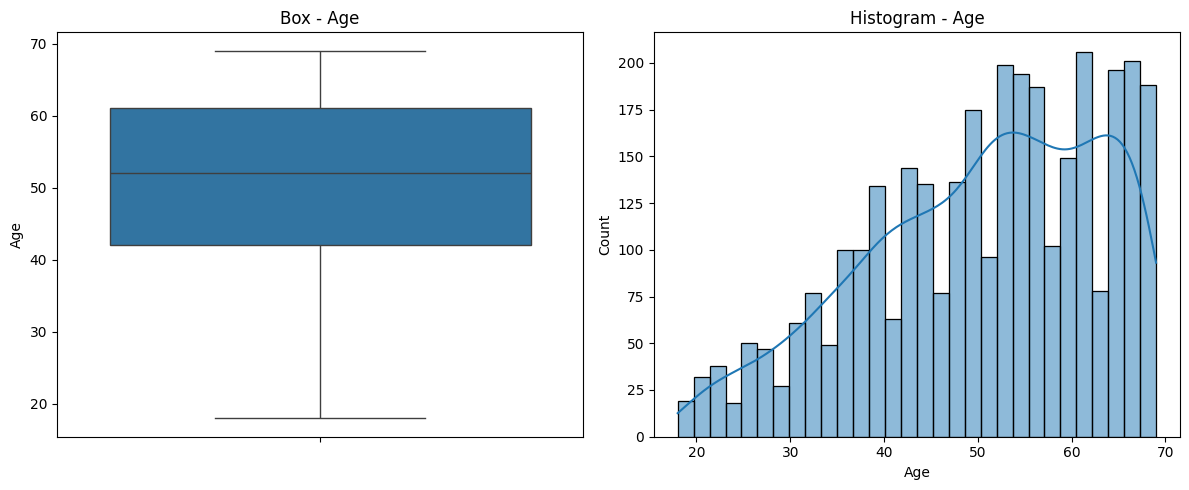

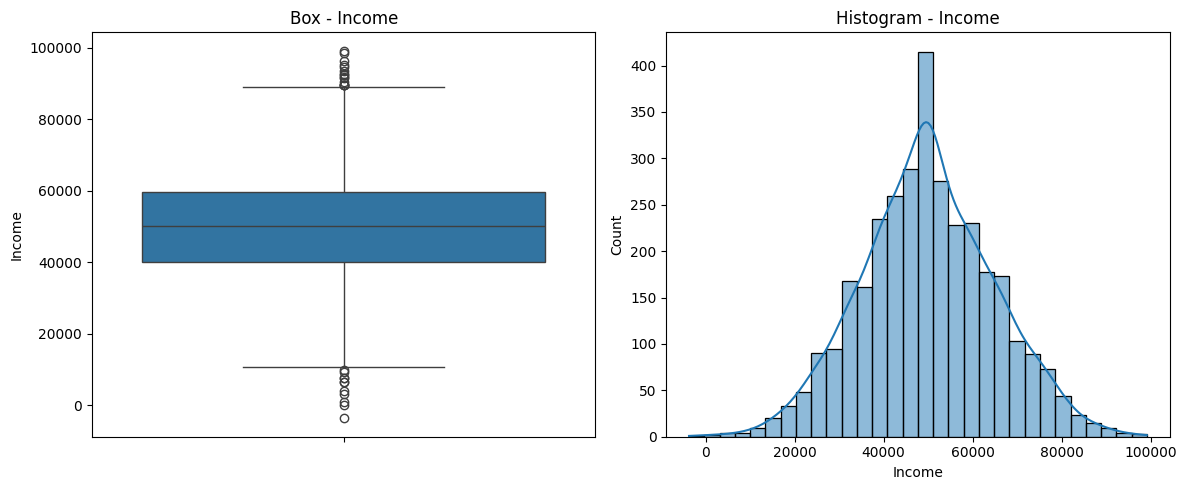

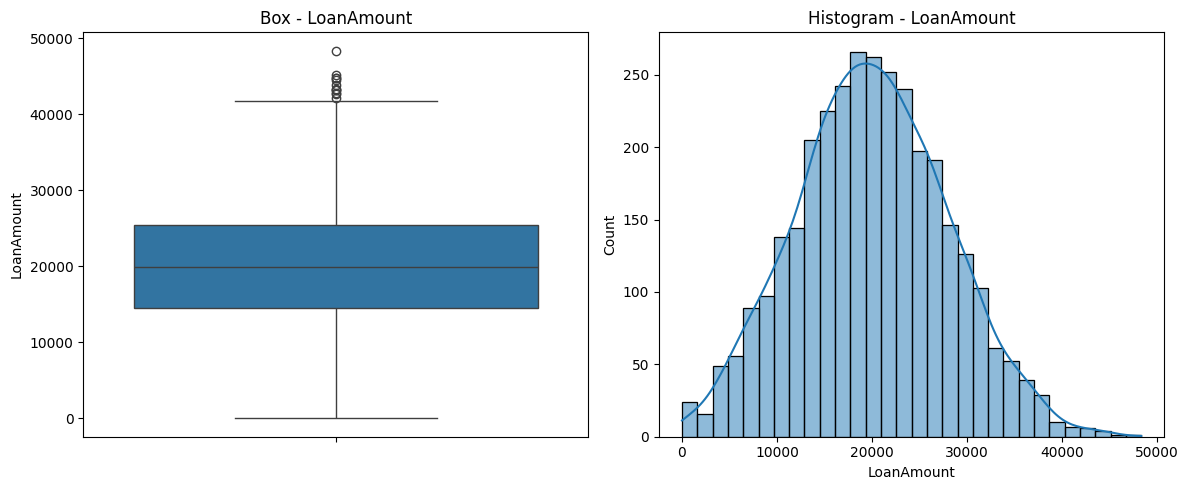

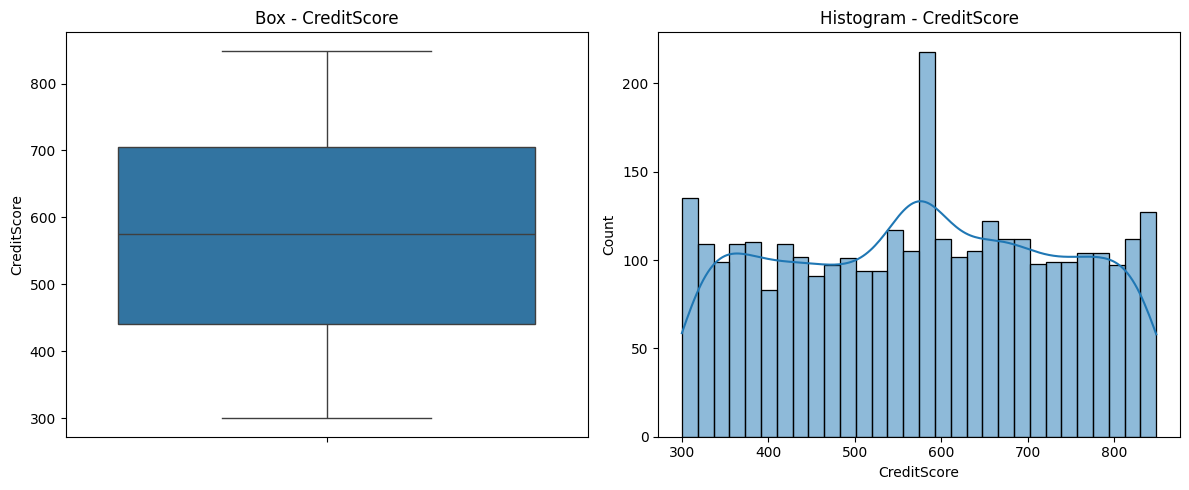

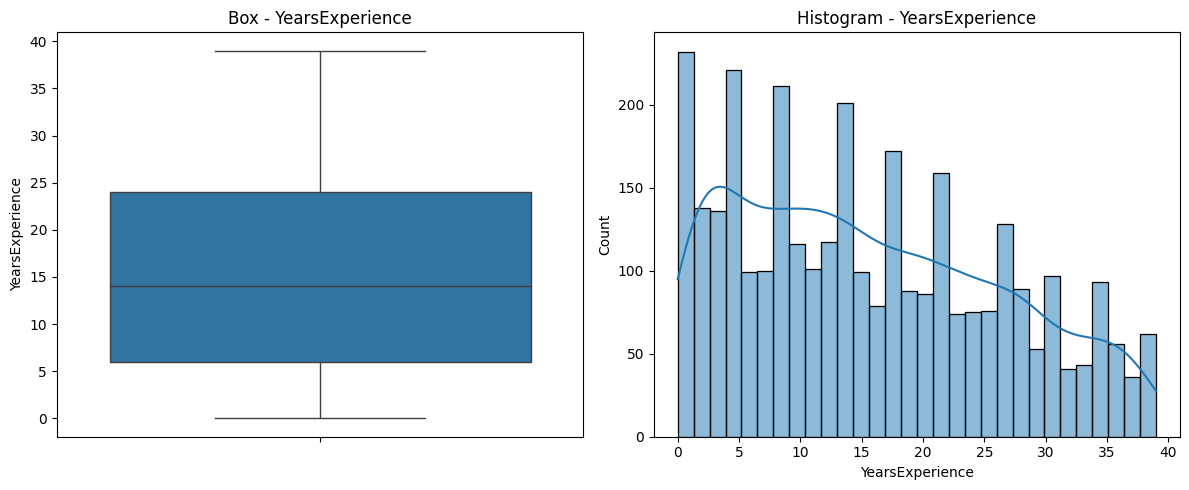

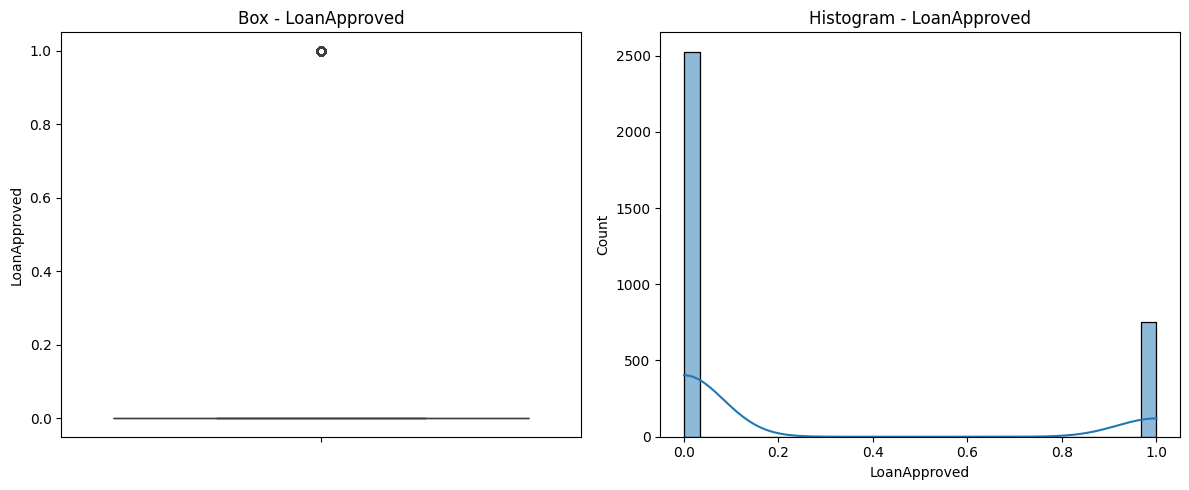

In [104]:
for col in df_clean.columns:
    if col not in ["Education", "Gender", "City", "EmploymentType"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Box plot
        sns.boxplot(y=df_clean[col], ax=axes[0])
        axes[0].set_title(f"Box - {col}")

        # Histogramme
        sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[1])
        axes[1].set_title(f"Histogram - {col}")
    
        plt.tight_layout()


Les valeurs atypiques seront gardées.

## Visualisation

### Segmentation des LoanApproved en fonction de Income et LoanAmount

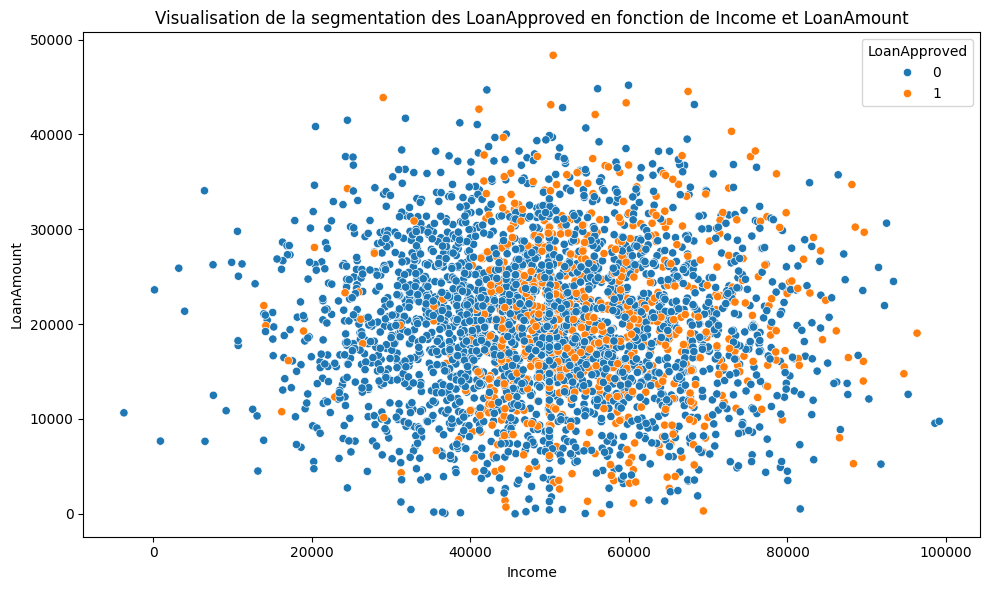

In [105]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Income', y='LoanAmount', hue='LoanApproved', data=df_clean)
plt.title('Visualisation de la segmentation des LoanApproved en fonction de Income et LoanAmount')
plt.tight_layout()
plt.show()

### Nuage de points des LoanApproved ou Not Approved en fonction de Income et de LoanAmount

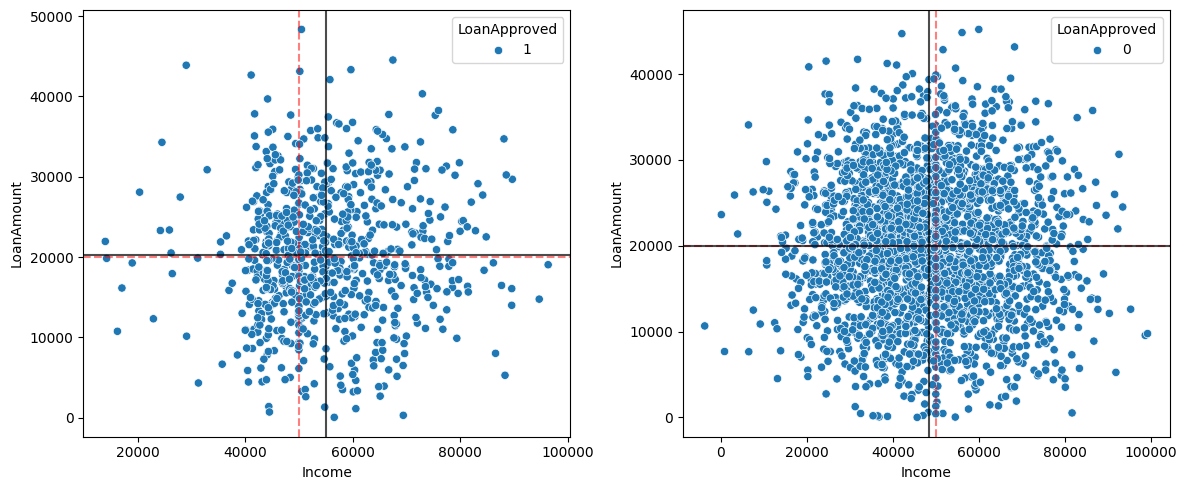

In [106]:
df_1 = df_clean[df_clean["LoanApproved"]==1]
df_0 = df_clean[df_clean["LoanApproved"]==0]

mean_income = df_clean["Income"].mean()
mean_loan = df_clean["LoanAmount"].mean()

mean_income_1 = df_1["Income"].mean()
mean_loan_1 = df_1["LoanAmount"].mean()

mean_income_0 = df_0["Income"].mean()
mean_loan_0 = df_0["LoanAmount"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='Income', y='LoanAmount', hue='LoanApproved', data=df_1, ax=axes[0])
sns.scatterplot(x='Income', y='LoanAmount', hue='LoanApproved', data=df_0, ax=axes[1])

# moyennes globales
for ax in axes:
    ax.axvline(mean_income, color='red', linestyle='--', alpha=0.5)
    ax.axhline(mean_loan, color='red', linestyle='--', alpha=0.5)

# moyennes pour LoanApproved = 1
axes[0].axvline(mean_income_1, color='black', linestyle='-', alpha=0.7)
axes[0].axhline(mean_loan_1, color='black', linestyle='-', alpha=0.7)

# moyennes pour LoanApproved = 0
axes[1].axvline(mean_income_0, color='black', linestyle='-', alpha=0.7)
axes[1].axhline(mean_loan_0, color='black', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

### Segmentation des LoanApproved en fonction de Income et LoanAmount

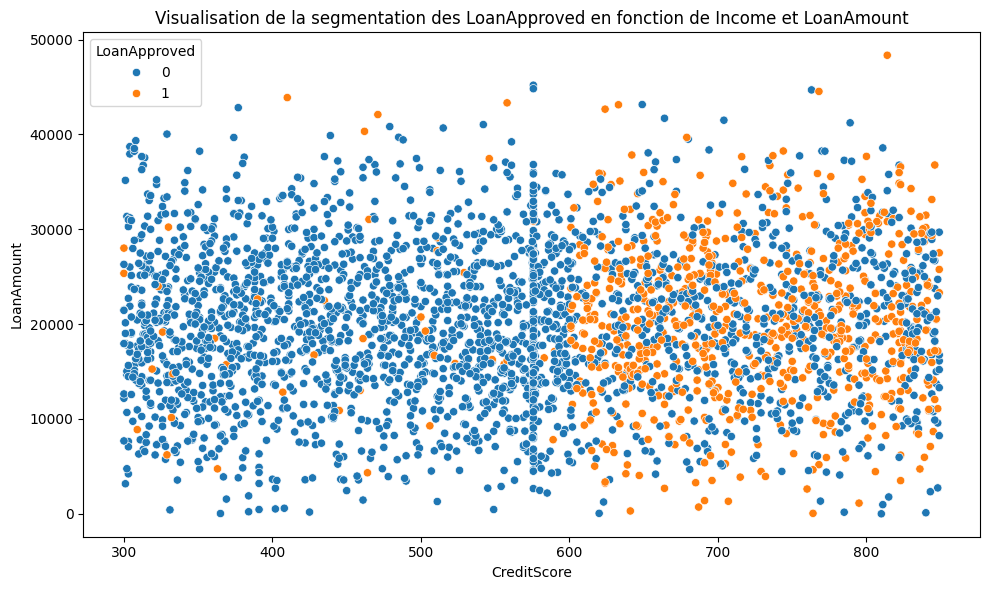

In [107]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='CreditScore', y='LoanAmount', hue='LoanApproved', data=df_clean)
plt.title('Visualisation de la segmentation des LoanApproved en fonction de Income et LoanAmount')
plt.tight_layout()
plt.show()

### Nuage de points des LoanApproved ou Not Approved en fonction de CreditScore et de LoanAmount

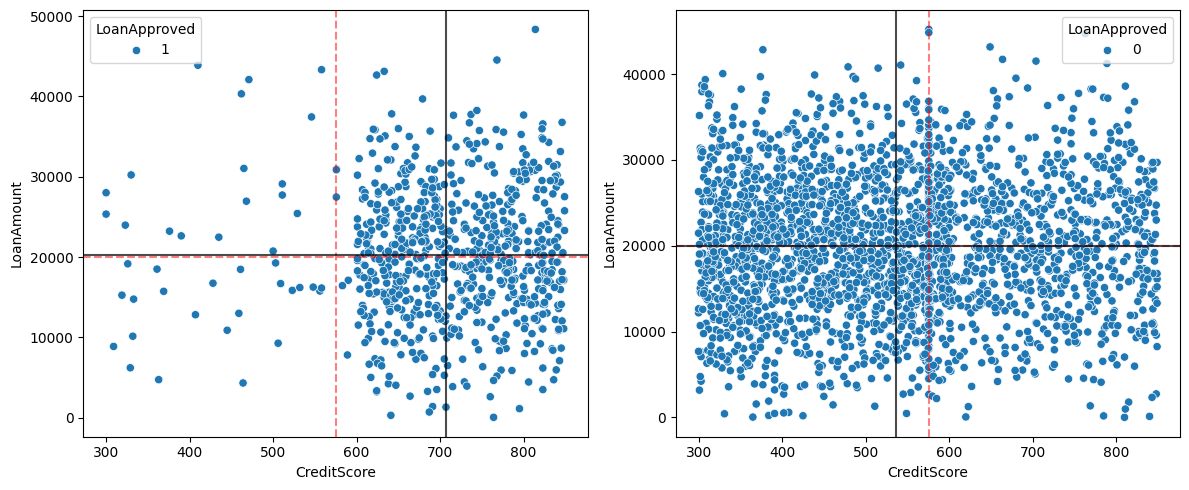

In [108]:
mean_creditscore = df_clean["CreditScore"].mean()
mean_loan = df_clean["LoanAmount"].mean()

mean_creditscore_1 = df_1["CreditScore"].mean()
mean_loan_1 = df_1["LoanAmount"].mean()

mean_creditscore_0 = df_0["CreditScore"].mean()
mean_loan_0 = df_0["LoanAmount"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='CreditScore', y='LoanAmount', hue='LoanApproved', data=df_1, ax=axes[0])
sns.scatterplot(x='CreditScore', y='LoanAmount', hue='LoanApproved', data=df_0, ax=axes[1])

# moyennes globales
for ax in axes:
    ax.axvline(mean_creditscore, color='red', linestyle='--', alpha=0.5)
    ax.axhline(mean_loan, color='red', linestyle='--', alpha=0.5)

# moyennes pour LoanApproved = 1
axes[0].axvline(mean_creditscore_1, color='black', linestyle='-', alpha=0.7)
axes[0].axhline(mean_loan_1, color='black', linestyle='-', alpha=0.7)

# moyennes pour LoanApproved = 0
axes[1].axvline(mean_creditscore_0, color='black', linestyle='-', alpha=0.7)
axes[1].axhline(mean_loan_0, color='black', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

### Segmentation des LoanApproved en fonction de CreditScore et Income

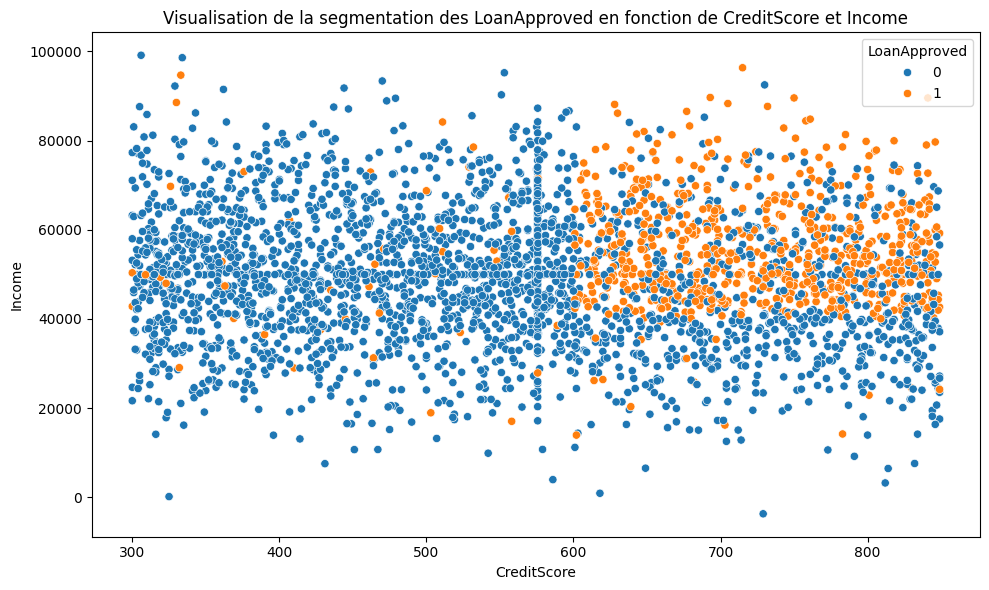

In [109]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='CreditScore', y='Income', hue='LoanApproved', data=df_clean)
plt.title('Visualisation de la segmentation des LoanApproved en fonction de CreditScore et Income')
plt.tight_layout()
plt.show()

### Nuage de points des LoanApproved ou Not Approved en fonction de CreditScore et de Income

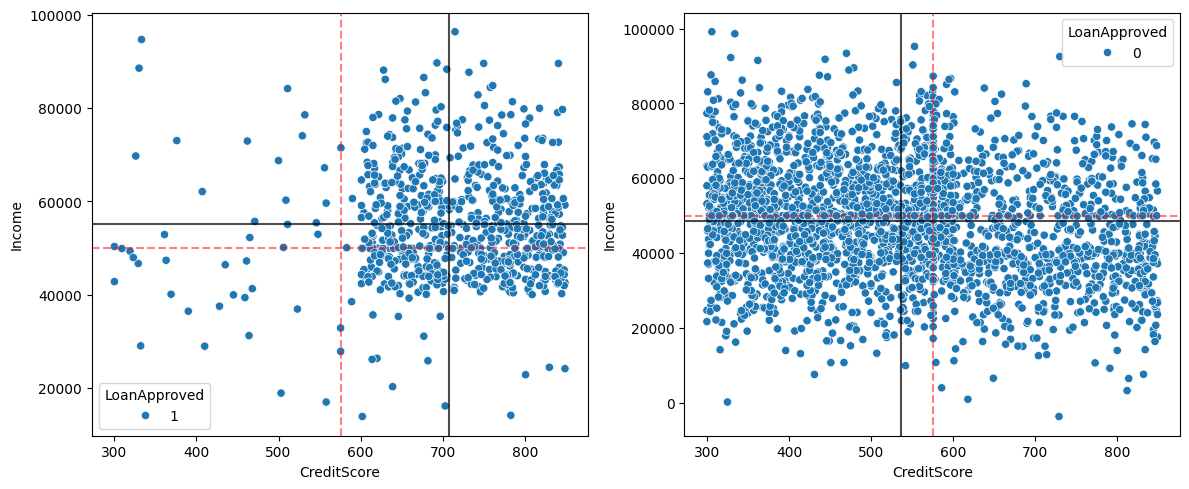

In [110]:
mean_creditscore = df_clean["CreditScore"].mean()
mean_income = df_clean["Income"].mean()

mean_creditscore_1 = df_1["CreditScore"].mean()
mean_income_1 = df_1["Income"].mean()

mean_creditscore_0 = df_0["CreditScore"].mean()
mean_income_0 = df_0["Income"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='CreditScore', y='Income', hue='LoanApproved', data=df_1, ax=axes[0])
sns.scatterplot(x='CreditScore', y='Income', hue='LoanApproved', data=df_0, ax=axes[1])

# moyennes globales
for ax in axes:
    ax.axvline(mean_creditscore, color='red', linestyle='--', alpha=0.5)
    ax.axhline(mean_income, color='red', linestyle='--', alpha=0.5)

# moyennes LoanApproved = 1
axes[0].axvline(mean_creditscore_1, color='black', linestyle='-', alpha=0.7)
axes[0].axhline(mean_income_1, color='black', linestyle='-', alpha=0.7)

# moyennes LoanApproved = 0
axes[1].axvline(mean_creditscore_0, color='black', linestyle='-', alpha=0.7)
axes[1].axhline(mean_income_0, color='black', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

## Encodage des variables

In [111]:
for quali in ["Education", "Gender", "City", "EmploymentType"]:
    print(df_clean[quali].value_counts())

Education
PhD            942
High School    791
Bachelors      788
Masters        757
Name: count, dtype: int64
Gender
Male      1655
Female    1623
Name: count, dtype: int64
City
Chicago          860
San Francisco    830
New York         803
Houston          785
Name: count, dtype: int64
EmploymentType
Self-Employed    1141
Unemployed       1076
Salaried         1061
Name: count, dtype: int64


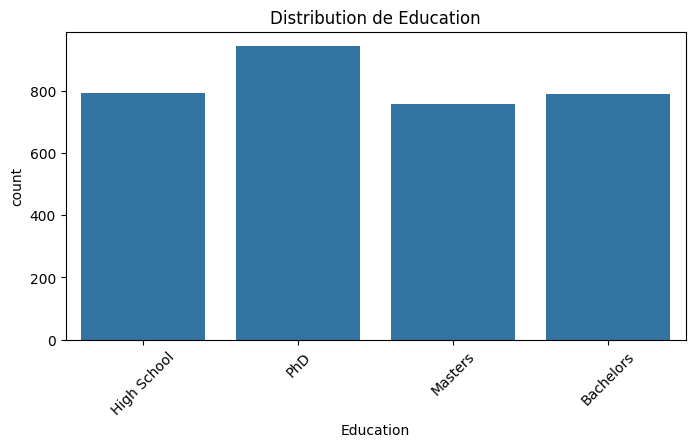

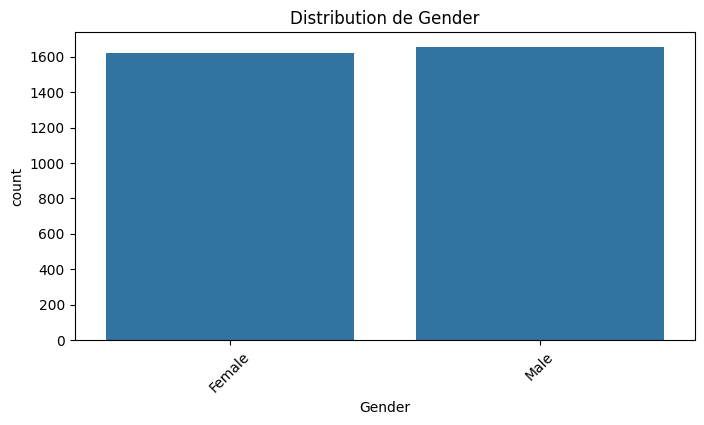

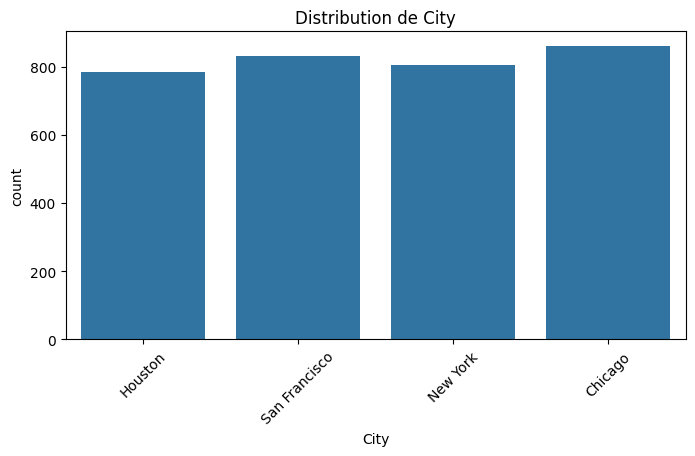

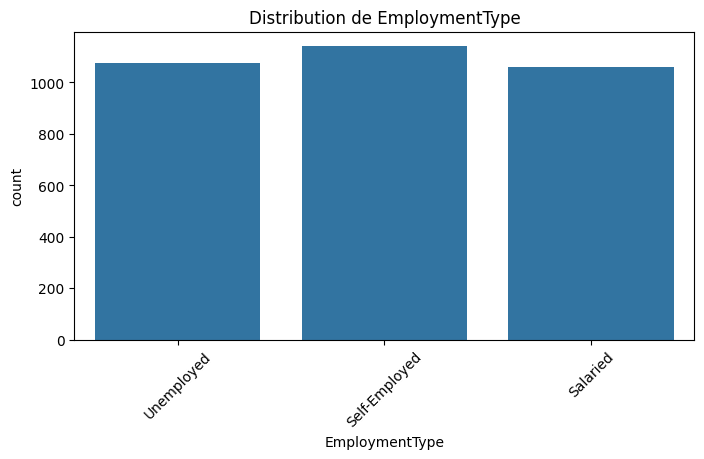

In [112]:
for var in ["Education", "Gender", "City", "EmploymentType"]:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df_clean[var])
    plt.title(f"Distribution de {var}")
    plt.xticks(rotation=45)
    plt.show()

Le nombre d'occurence pour chacune des modalités est proche, de plus il y a peu de modalités, donc nous utiliserons la fonction get_dummies de pandas

In [113]:
# Chaque modalité va avoir une colonne binaire
for quali in ["Education", "Gender", "City", "EmploymentType"]:
    dummies = pd.get_dummies(df_clean[quali], drop_first=True)
    df_clean = pd.concat([df_clean, dummies], axis=1)
    df_clean.drop(columns=quali, inplace=True)

# remplace True par 1 et False 0    
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [114]:
print(df_clean.head())
print(df_clean.columns)

   Age   Income  LoanAmount  CreditScore  YearsExperience  LoanApproved  \
0   56  48353.0     31258.0        675.0               20             0   
1   69  57462.0     23262.0        586.0                6             0   
2   46  44219.0     26530.0        781.0               26             1   
3   32  56307.0     11531.0        549.0               11             0   
4   60  37034.0     27871.0        500.0               19             0   

   High School  Masters  PhD  Male  Houston  New York  San Francisco  \
0            1        0    0     0        1         0              0   
1            1        0    0     1        0         0              1   
2            0        0    1     1        1         0              0   
3            0        0    1     1        0         1              0   
4            1        0    0     0        0         0              0   

   Self-Employed  Unemployed  
0              0           1  
1              1           0  
2              1       

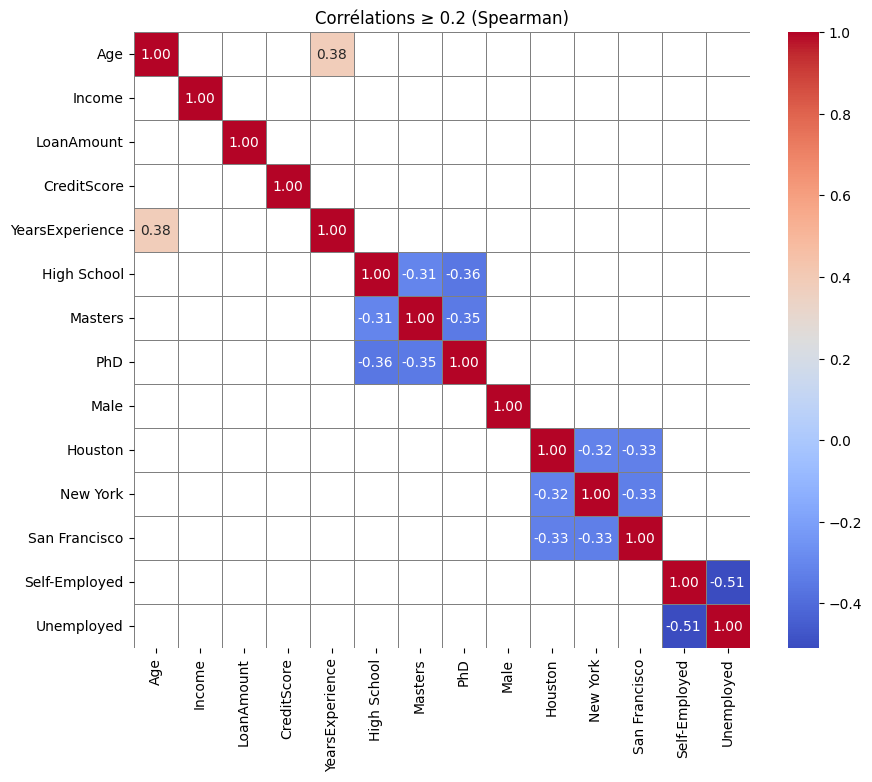

In [115]:
df_Loan = df_clean.drop(columns=["LoanApproved"]) # la variable binaire

# Sélectionner uniquement les colonnes numériques
df_numeric = df_Loan.select_dtypes(include=[np.number])

# Calculer la corrélation Spearman
corr = df_numeric.corr(method='spearman')

# Masquer les valeurs < 0.2
corr_high = corr.mask(abs(corr) < 0.2)

# Créer une figure
plt.figure(figsize=(10, 8))

# Afficher la heatmap
sns.heatmap(corr_high, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            linewidths=0.5, linecolor="gray", mask=corr_high.isna())

plt.title("Corrélations ≥ 0.2 (Spearman)")
plt.show()



Les variables ne sont pas corrélées entre elles

## Séparation du jeu de données en train et test 80/20

In [116]:
X_train, X_test, y_train, y_test = train_test_split(df_clean.iloc[:, df_clean.columns != "LoanApproved"],
                                                    df_clean["LoanApproved"],
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 42)

## Standardisation

In [117]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

## Équilibrage de notre variable cible

Text(0.5, 1.0, 'Overall Loan Approval Distribution')

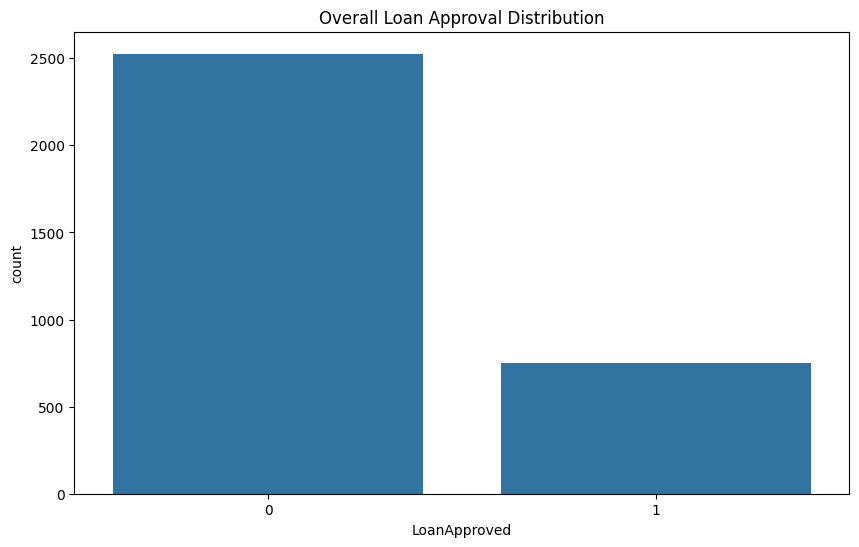

In [118]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='LoanApproved', data=df_clean)
plt.title('Overall Loan Approval Distribution')

On voit ici que la distribution des crédit alloués est bien plus faible que celle des crédit non alloués. Pour permettre un meilleur apprentissage via ce jeu de données déséquilibré, on va réduire la classe majoritaire via la fonction **Under-Sampling**

In [119]:
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_sc, y_train)

## Modèle de classification

### Non linéaire

In [120]:
# ── 1. Choisir 2 features pour la visualisation ──────────────
# Si X_train_sc a plus de 2 colonnes, on en sélectionne 2
feature_idx = [0, 1]  # index des 2 features à afficher
X2 = X_train_res[:, feature_idx]

#from sklearn.decomposition import PCA
# X2 = PCA(n_components=2).fit_transform(X_train_res)

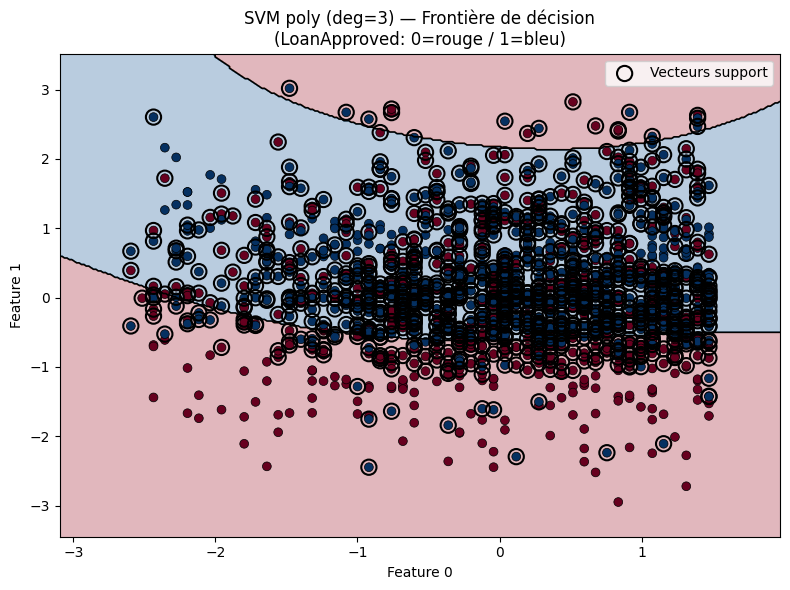

In [121]:



# ── 2. Réentraîner le SVM sur ces 2 features ────────────────
svm2 = SVC(kernel="poly", degree=3, C=50, coef0=1)
svm2.fit(X2, y_train_res)

# ── 3. Créer la grille de points ─────────────────────────────
x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# ── 4. Prédire sur la grille ─────────────────────────────────
Z = svm2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ── 5. Tracer la frontière ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
ax.contour(xx, yy, Z, colors="black", linewidths=1.2, levels=[0.5])

# Points d'entraînement
scatter = ax.scatter(
    X2[:, 0], X2[:, 1],
    c=y_train_res, cmap="RdBu",
    edgecolors="k", linewidths=0.5, s=40
)

# Vecteurs support
ax.scatter(
    svm2.support_vectors_[:, 0],
    svm2.support_vectors_[:, 1],
    s=120, facecolors="none",
    edgecolors="black", linewidths=1.5,
    label="Vecteurs support", zorder=5
)

ax.set_xlabel(f"Feature {feature_idx[0]}")
ax.set_ylabel(f"Feature {feature_idx[1]}")
ax.set_title("SVM poly (deg=3) — Frontière de décision\n(LoanApproved: 0=rouge / 1=bleu)")
ax.legend()
plt.tight_layout()
plt.show()
